# Tarea 2 Panel y Pseudo-experimentos - Pauta

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
import linearmodels.panel as lmp
import pytwoway as tw
import bipartitepandas as bpd
import seaborn as sns
from linearmodels.iv import IV2SLS

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

print("Librerías cargadas.");

Librerías cargadas.


Preguntas:

1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. 

In [104]:
df = pd.read_csv("../data/panel_eps.csv")
df.loc[(df["kids"] == 0) & (df["children"].isna()), "children"] = 0 #Si no tiene hijos y en childresn tiene NaN, rellenar con 0
df[df["situation"] == 2][["size", "occupation", "wage", "hours", "informal", "selfemp", "publicemp"]]
cols = ["size", "occupation", "wage", "hours", "informal", "selfemp", "publicemp"]
df.loc[df["situation"].isin([2, 4]), cols] = df.loc[df["situation"].isin([2, 4]), cols].fillna(0)
df["wage"] = np.log(df["wage"] + 0.1)
df["assets"] = np.log(df["assets"] + 0.1)
df.loc[df['situation'] != 3, 'situation'] = 0
df.loc[df['situation'] == 3, 'situation'] = 1
df.loc[df['status'] == 2, 'status'] = 1
df.loc[df['status'] >2, 'status'] = 0
df.loc[df['exp'].isna(), 'exp'] = 0
df = df[(~df["expectancy"].isna()) & (df["expectancy"] < 130)]
df.reset_index(drop=True, inplace=True)
df = df.set_index(["folio_n20","time"])
df.describe()

,year,edad,hombre,edu,region,status,kids,children,situation,lmp,...,fondob,fondoc,fondod,fondoe,exp_sist,expectancy,illness,cronica,nocronica,mental
count,66091.000000,66091.000000,66067.000000,65104.000000,53498.000000,66043.000000,66091.000000,66091.000000,66091.000000,66091.000000,...,0.0,0.0,0.0,0.0,66091.000000,66091.000000,49990.000000,50079.000000,50079.000000,50079.000000
mean,6.191705,1708.111029,0.507848,8.168346,9.099518,0.589101,0.417954,0.706950,0.609780,1.183535,...,NaN,NaN,NaN,NaN,13.276044,76.718751,0.324445,0.206554,0.065616,0.067573
std,3.603539,676.720675,0.499942,5.131802,3.669517,0.492001,0.493226,1.009009,0.487803,0.964522,...,NaN,NaN,NaN,NaN,9.442168,10.597918,0.468172,0.404836,0.247613,0.251015
min,2.000000,20.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,1982.000000,0.000000,4.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,4.000000,70.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,1984.000000,1.000000,8.000000,9.000000,1.000000,0.000000,0.000000,1.000000,2.000000,...,NaN,NaN,NaN,NaN,14.000000,80.000000,0.000000,0.000000,0.000000,0.000000
75%,9.000000,1989.000000,1.000000,12.000000,13.000000,1.000000,1.000000,1.000000,1.000000,2.000000,...,NaN,NaN,NaN,NaN,22.000000,80.000000,1.000000,0.000000,0.000000,0.000000
max,12.000000,1993.000000,1.000000,19.000000,15.000000,1.000000,1.000000,8.000000,1.000000,2.000000,...,NaN,NaN,NaN,NaN,32.000000,129.000000,1.000000,1.000000,1.000000,1.000000


### 2. Ejecute un modelo Pooled OLS para estimar la relacion entre la educacion y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [105]:
df = df[df['year'] != 2]
y = df['expectancy'];
X=df[[
      'edu',
      'children',
      'exp',
      'status',
      "wage",
      "publicemp",
      "cronica",
      "nocronica",
      "mental",
      "situation",
      #'hombre',
      "year",
      ]]
X=sm.add_constant(X)
X.describe()

,const,edu,children,exp,status,wage,publicemp,cronica,nocronica,mental,situation,year
count,50079.0,49513.000000,50079.000000,50079.000000,50031.000000,49017.000000,49914.000000,50079.000000,50079.000000,50079.000000,50079.000000,50079.000000
mean,1.0,8.166946,0.630963,11.299267,0.578561,6.242891,0.063209,0.206554,0.065616,0.067573,0.595998,7.531940
std,0.0,5.055948,0.960550,9.882207,0.493794,7.175975,0.243340,0.404836,0.247613,0.251015,0.490703,3.118212
min,1.0,0.000000,0.000000,0.000000,0.000000,-2.302585,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
25%,1.0,4.000000,0.000000,1.000000,0.000000,-2.302585,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
50%,1.0,8.000000,0.000000,10.000000,1.000000,11.608237,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000
75%,1.0,12.000000,1.000000,21.000000,1.000000,12.301383,0.000000,0.000000,0.000000,0.000000,1.000000,12.000000
max,1.0,19.000000,8.000000,33.000000,1.000000,16.811243,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000


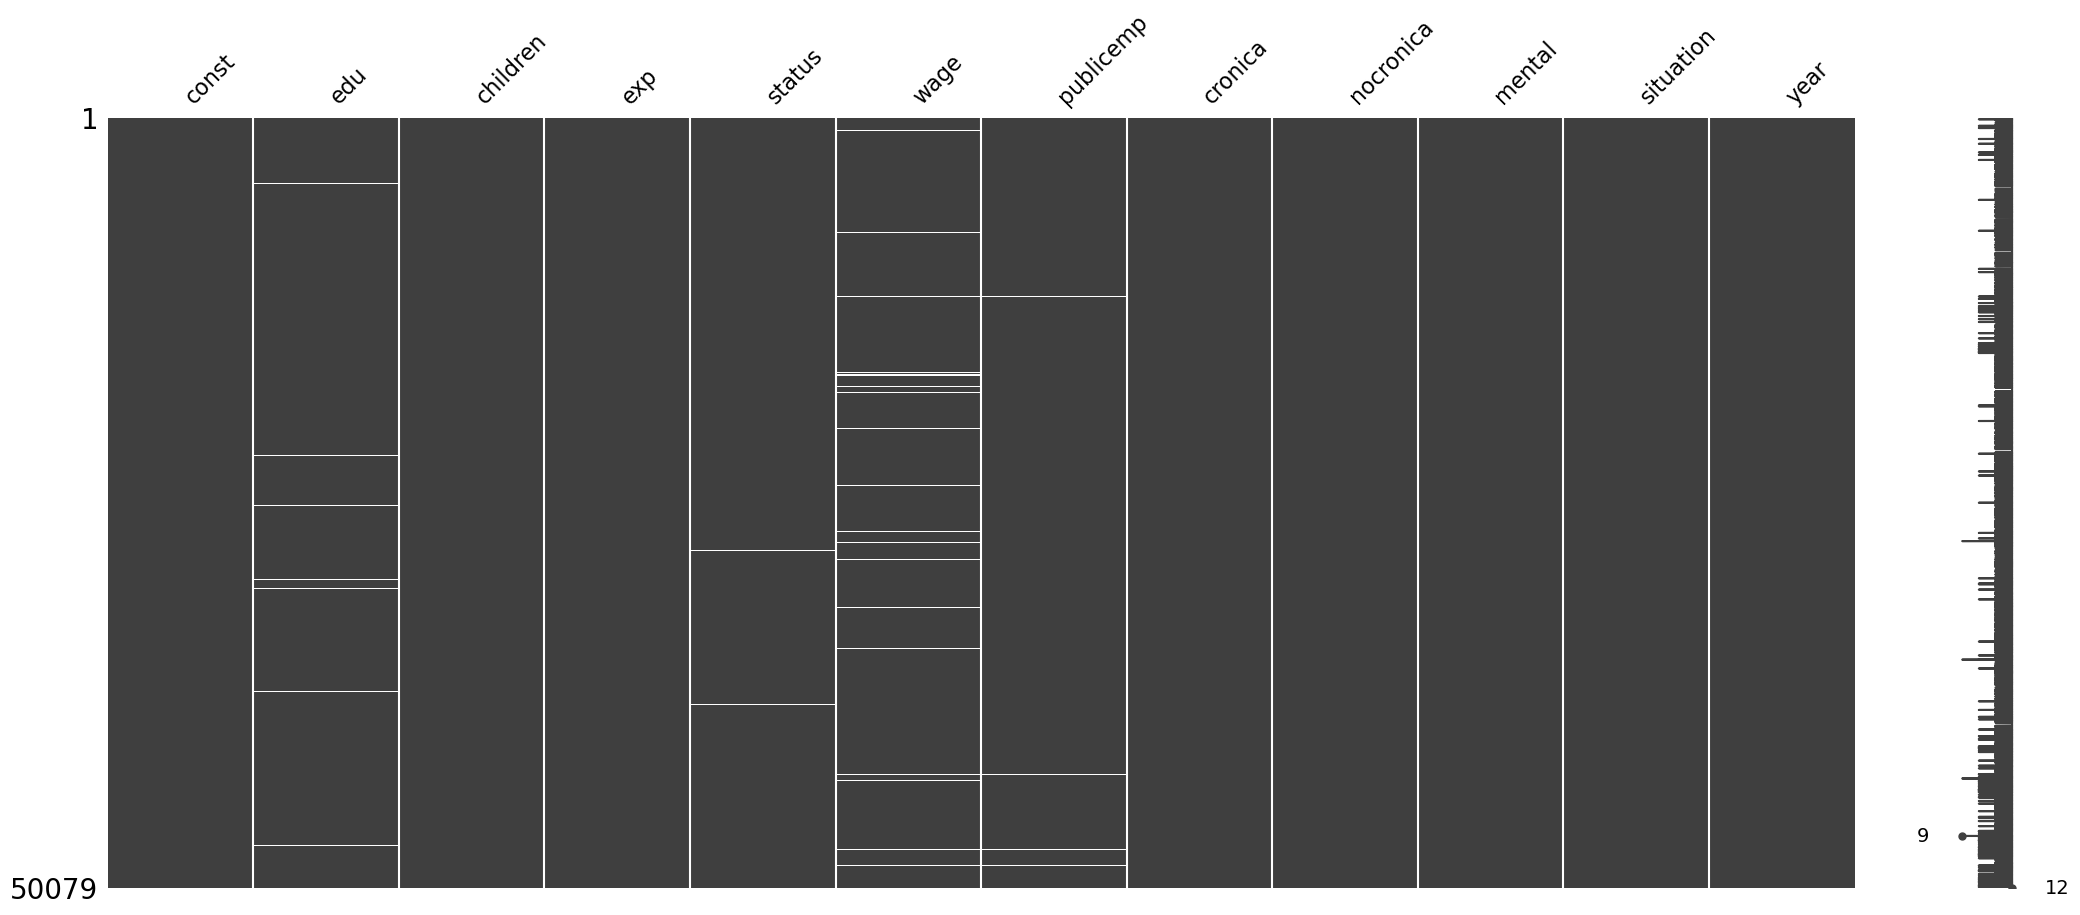

In [106]:
import missingno as msno
plt.show(msno.matrix(X))

<Axes: xlabel='expectancy', ylabel='Count'>

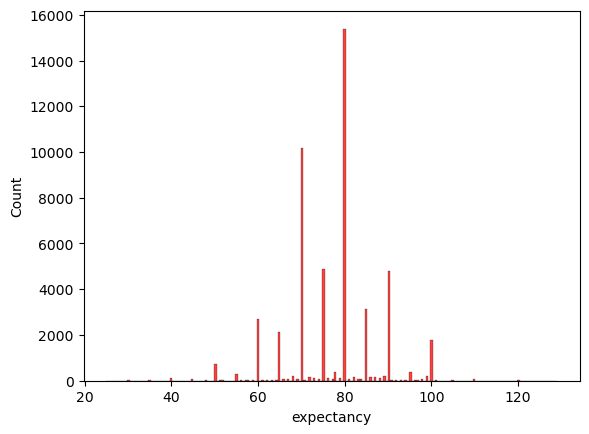

In [107]:
sns.histplot(data=y, color="red", label="unobserved heterogeneity", kde=False)

In [108]:
model = lmp.PanelOLS(y, X);
mco = model.fit(cov_type="robust");
print(mco)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0225
Estimator:                   PanelOLS   R-squared (Between):              0.0219
No. Observations:               48423   R-squared (Within):               0.0157
Date:                Thu, Jun 05 2025   R-squared (Overall):              0.0225
Time:                        10:15:02   Log-likelihood                -1.814e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      101.34
Entities:                       23516   P-value                           0.0000
Avg Obs:                       2.0592   Distribution:                F(11,48411)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             91.420
                            

### 3. Ejecute un modelo efectos fijos para estimar la relacion entre la educacion y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [109]:
model = lmp.PanelOLS(y,X, entity_effects=True, drop_absorbed=True);
fe = model.fit(cov_type="robust");
print(fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0282
Estimator:                   PanelOLS   R-squared (Between):             -0.0177
No. Observations:               48423   R-squared (Within):               0.0282
Date:                Thu, Jun 05 2025   R-squared (Overall):             -0.0002
Time:                        10:15:03   Log-likelihood                -1.554e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      65.759
Entities:                       23516   P-value                           0.0000
Avg Obs:                       2.0592   Distribution:                F(11,24896)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             45.798
                            

### 4. Ejecute un modelo de efectos aleatorios para estimar la relacion entre la educacion y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. 

In [110]:
model = lmp.RandomEffects(y,X);
re = model.fit(cov_type="robust")
print(re)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4162
Estimator:              RandomEffects   R-squared (Between):              0.0195
No. Observations:               48423   R-squared (Within):               0.0205
Date:                Thu, Jun 05 2025   R-squared (Overall):              0.0216
Time:                        10:15:03   Log-likelihood                -1.717e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      3137.9
Entities:                       23516   P-value                           0.0000
Avg Obs:                       2.0592   Distribution:                F(11,48411)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             87.448
                            

### 5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

In [111]:
import numpy.linalg as la
from scipy import stats
def hausman(fe, re):
    diff = fe.params-re.params
    psi = fe.cov - re.cov
    dof = diff.size -1
    W = diff.dot(la.inv(psi)).dot(diff)
    pval = stats.chi2.sf(W, dof)
    return W, dof, pval
htest = hausman(fe, re)
print("Hausman Test: chi-2 = {0}, df = {1}, p-value = {2}".format(htest[0], htest[1], htest[2]))

Hausman Test: chi-2 = 215.88420252751706, df = 11, p-value = 3.716701637372101e-40


In [112]:
print(lmp.compare({"FE": fe, "RE": re, "Pooled": mco}))

                            Model Comparison                           
                                    FE                RE         Pooled
-----------------------------------------------------------------------
Dep. Variable               expectancy        expectancy     expectancy
Estimator                     PanelOLS     RandomEffects       PanelOLS
No. Observations                 48423             48423          48423
Cov. Est.                       Robust            Robust         Robust
R-squared                       0.0282            0.4162         0.0225
R-Squared (Within)              0.0282            0.0205         0.0157
R-Squared (Between)            -0.0177            0.0195         0.0219
R-Squared (Overall)            -0.0002            0.0216         0.0225
F-statistic                     65.759            3137.9         101.34
P-value (F-stat)                0.0000            0.0000         0.0000
=====================     ============   ===============   =====

### 6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la relacion entre las cuarentenas dinamicas y la calidad del aire. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

En el análisis se debe incluir la significancia de las variables, los coeficientes y una explicación hacia la variable dependiente. En adición, se debe explicar la incorporación de variables para explicar heterogeneidad no observada.

In [129]:
vars_continuas_base = ['edu', 'exp', 'wage', "cronica", "nocronica", "mental"]
Xm = df.groupby('folio_n20')[vars_continuas_base].transform('mean')
Xm.columns = ['m_' + col for col in Xm.columns]  # Renombrar
X_cre = pd.merge(X,Xm, left_index=True, right_index=True)
model=lmp.RandomEffects(y,X_cre)
cre=model.fit(cov_type="robust")
print(cre)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4189
Estimator:              RandomEffects   R-squared (Between):              0.0243
No. Observations:               48423   R-squared (Within):               0.0252
Date:                Thu, Jun 05 2025   R-squared (Overall):              0.0265
Time:                        10:24:47   Log-likelihood                -1.716e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      2052.8
Entities:                       23516   P-value                           0.0000
Avg Obs:                       2.0592   Distribution:                F(17,48405)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             71.563
                            

### 7. Usando el modelo CRE, prediga la distribucion del componente no observado. Que puede inferir respecto de la heterogeneidad fija en el tiempo y su impacto en la expectativa de vida?

In [130]:
Xpred = X_cre
Xpred['edu'] = 0
Xpred['children'] = 0
Xpred['exp'] = 0
Xpred['wage'] = 0
Xpred['status'] = 0
Xpred['publicemp'] = 0
Xpred['cronica'] = 0
Xpred['nocronica'] = 0
Xpred['mental'] = 0
Xpred['situation'] = 0
Xpred['year'] = 0


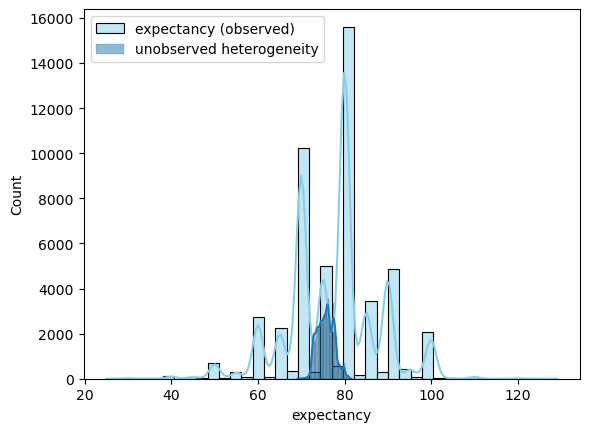

In [131]:
yhat = cre.predict(X_cre)

sns.histplot(data=y, color="skyblue", label="expectancy (observed)", kde=True, bins=40)
sns.histplot(data=yhat, color="red", label="unobserved heterogeneity", kde=True, bins=40)

plt.legend()
plt.show()

### 8. Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las variables explicativas sobre la expectativa de vida?

En vista de las comparaciones anteriores, tendría sentido escoger el modelo CRE pro sobre los otros.

In [132]:
print(lmp.compare({"FE": fe, "RE": re, "CRE": cre}))

                             Model Comparison                             
                                    FE                RE               CRE
--------------------------------------------------------------------------
Dep. Variable               expectancy        expectancy        expectancy
Estimator                     PanelOLS     RandomEffects     RandomEffects
No. Observations                 48423             48423             48423
Cov. Est.                       Robust            Robust            Robust
R-squared                       0.0282            0.4162            0.4189
R-Squared (Within)              0.0282            0.0205            0.0252
R-Squared (Between)            -0.0177            0.0195            0.0243
R-Squared (Overall)            -0.0002            0.0216            0.0265
F-statistic                     65.759            3137.9            2052.8
P-value (F-stat)                0.0000            0.0000            0.0000
=====================    

### 9. Es posible que sus resultados anteriores tengan sesgo dado que las cuarentenas (paso a paso) son endogenas al comportamiento de las personas. Construya AL MENOS DOS instrumentos posibles para las cuarentenas dinamicas, de forma que se pueda corregir el sesgo y entender el efecto causal de las cuarentenas en el aire. Realice su estimacion considerando un modelo agrupado (ignorando el tiempo), y el modelo de panel.